In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
import re
import json

# 设置绘图风格
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 11

# 数据目录
base_dir = Path("/home/bxb1/vllm_workbench/vllm/new-logs/project-kernal_cmp_9")

# 收集所有测试目录
test_dirs = list(base_dir.glob("test-*"))

def parse_dir_name(dirname):
    """从目录名解析参数"""
    params = {}
    pattern = r'\{(\w+)=([^}]+)\}'
    matches = re.findall(pattern, dirname)
    for key, value in matches:
        params[key] = value
    return params

def extract_aggregate_section(text):
    """提取 benchmark.log 中最终的 aggregate statistics 区域"""
    marker = 'AGGREGATE STATISTICS ACROSS'
    if marker not in text:
        return ''
    return marker + text.rsplit(marker, 1)[-1]

def parse_section_stats(section_text, section_name):
    """从 aggregate statistics 中解析 Average / Std Dev"""
    pattern = (
        rf"{re.escape(section_name)}:\s*\n"
        rf"\s*Average:\s*([0-9.]+)\s*\n"
        rf"\s*Median:\s*[0-9.]+\s*\n"
        rf"\s*Std Dev:\s*([0-9.]+)"
    )
    match = re.search(pattern, section_text, re.MULTILINE)
    if not match:
        return None
    return {
        'avg': float(match.group(1)),
        'std': float(match.group(2)),
    }

def parse_benchmark_log(log_file):
    """从 benchmark.log 最终汇总中提取聚合均值和标准差"""
    if not log_file.exists():
        return {}

    text = log_file.read_text(encoding='utf-8', errors='ignore')
    aggregate_section = extract_aggregate_section(text)
    if not aggregate_section:
        return {}

    stats = {}

    output_throughput = parse_section_stats(
        aggregate_section, 'OUTPUT THROUGHPUT (tokens/s)'
    )
    if output_throughput:
        stats['throughput'] = output_throughput

    ttft = parse_section_stats(
        aggregate_section, 'MEAN TTFT ACROSS REPETITIONS (ms)'
    )
    if ttft:
        stats['ttft_ms'] = ttft

    tpot = parse_section_stats(
        aggregate_section, 'MEAN TPOT ACROSS REPETITIONS (ms)'
    )
    if tpot:
        stats['tpot_ms'] = tpot

    e2el = parse_section_stats(
        aggregate_section, 'MEAN E2EL ACROSS REPETITIONS (ms)'
    )
    if e2el:
        stats['e2el_s'] = {
            'avg': e2el['avg'] / 1000,
            'std': e2el['std'] / 1000,
        }

    normalized_latency = parse_section_stats(
        aggregate_section, 'MEAN NORMALIZED LATENCY ACROSS REPETITIONS (ms/tok)'
    )
    if normalized_latency:
        stats['normalized_latency_ms'] = normalized_latency

    total_requests_match = re.search(
        r'Total Requests:\s*([0-9]+)', aggregate_section
    )
    if total_requests_match:
        stats['n_requests'] = int(total_requests_match.group(1))

    return stats

# 收集所有数据
all_data = []
for test_dir in test_dirs:
    params = parse_dir_name(test_dir.name)
    metrics_file = test_dir / "request_metrics.csv"
    benchmark_log_file = test_dir / "benchmark.log"

    df = pd.read_csv(metrics_file) if metrics_file.exists() else None

    # 默认从 request_metrics.csv 计算，作为 fallback
    if df is not None:
        avg_ttft = df['ttfts'].mean() * 1000  # 转换为毫秒
        std_ttft = df['ttfts'].std() * 1000
        avg_tpot = df['tpots'].mean() * 1000
        std_tpot = df['tpots'].std() * 1000
        avg_e2el = df['e2els'].mean()  # 秒
        std_e2el = df['e2els'].std()
    else:
        avg_ttft = std_ttft = np.nan
        avg_tpot = std_tpot = np.nan
        avg_e2el = std_e2el = np.nan

    # 优先从 benchmark.log 最终 aggregate statistics 提取跨 repetition 的 std dev
    benchmark_stats = parse_benchmark_log(benchmark_log_file)
    if 'ttft_ms' in benchmark_stats:
        avg_ttft = benchmark_stats['ttft_ms']['avg']
        std_ttft = benchmark_stats['ttft_ms']['std']
    if 'tpot_ms' in benchmark_stats:
        avg_tpot = benchmark_stats['tpot_ms']['avg']
        std_tpot = benchmark_stats['tpot_ms']['std']
    if 'e2el_s' in benchmark_stats:
        avg_e2el = benchmark_stats['e2el_s']['avg']
        std_e2el = benchmark_stats['e2el_s']['std']

    # 读取配置获取实际参数
    config_file = test_dir / "benchmark_config.json"
    if config_file.exists():
        with open(config_file) as f:
            config = json.load(f)
        # input_output_lens 是数组的数组 [[input_len, output_len]]
        input_output = config.get('input_output_lens', [[0, 0]])[0]
        input_len = input_output[0]
        output_len = input_output[1]
    else:
        input_len = int(params.get('in', 0))
        output_len = int(params.get('out', 0))

    # 计算 normalized latency = e2el / output_tokens (s per token)
    normalized_latency = avg_e2el / output_len if output_len > 0 else 0
    std_normalized_latency = std_e2el / output_len if output_len > 0 else 0

    # output throughput 优先使用 benchmark.log 里的 aggregate std dev
    if 'throughput' in benchmark_stats:
        avg_throughput = benchmark_stats['throughput']['avg']
        std_throughput = benchmark_stats['throughput']['std']
    elif df is not None:
        request_throughputs = output_len / df['e2els']
        avg_throughput = request_throughputs.mean()
        std_throughput = request_throughputs.std()
    else:
        avg_throughput = std_throughput = np.nan

    if 'normalized_latency_ms' in benchmark_stats:
        normalized_latency = benchmark_stats['normalized_latency_ms']['avg'] / 1000
        std_normalized_latency = benchmark_stats['normalized_latency_ms']['std'] / 1000

    all_data.append({
        'kernel': params.get('kernel'),
        'rr': float(params.get('rr', 0)),
        'input_len': input_len,
        'output_len': output_len,
        'scenario': f"in={input_len},out={output_len}",
        'ttft_ms': avg_ttft,
        'ttft_std': std_ttft,
        'tpot_ms': avg_tpot,
        'tpot_std': std_tpot,
        'e2el_s': avg_e2el,
        'e2el_std': std_e2el,
        'normalized_latency_ms': normalized_latency * 1000,
        'normalized_latency_std': std_normalized_latency * 1000,
        'throughput': avg_throughput,
        'throughput_std': std_throughput,
        'n_requests': benchmark_stats.get('n_requests', len(df) if df is not None else 0)
    })

df_all = pd.DataFrame(all_data)
print(df_all.sort_values(['scenario', 'rr']))


    kernel   rr  input_len  output_len        scenario  ttft_ms  ttft_std  \
3   direct  1.0        128         512  in=128,out=512   235.10      9.14   
10   flash  1.0        128         512  in=128,out=512   230.16      4.08   
0    flash  2.0        128         512  in=128,out=512   256.86     11.24   
1   direct  2.0        128         512  in=128,out=512   251.61     12.30   
8    flash  3.0        128         512  in=128,out=512   266.36     10.91   
11  direct  3.0        128         512  in=128,out=512   253.75      8.53   
7   direct  1.0        512          16   in=512,out=16   562.00      2.96   
9    flash  1.0        512          16   in=512,out=16   566.94      1.32   
2    flash  2.0        512          16   in=512,out=16  2887.89     76.06   
4   direct  2.0        512          16   in=512,out=16  2219.40    738.55   
5   direct  3.0        512          16   in=512,out=16  9828.19     40.68   
6    flash  3.0        512          16   in=512,out=16  9800.41     45.59   

In [6]:
# 绘制折线图比较两个kernel
# 分开 decode-heavy 和 prefill-heavy 两种 workload

# 定义workload类型
def get_workload_type(row):
    if row['input_len'] == 128 and row['output_len'] == 512:
        return 'Decode Heavy (in=128, out=512)'
    elif row['input_len'] == 512 and row['output_len'] == 16:
        return 'Prefill Heavy (in=512, out=16)'
    else:
        return 'Unknown'

df_all['workload'] = df_all.apply(get_workload_type, axis=1)

# 分离两种workload
df_decode = df_all[df_all['workload'].str.contains('Decode')].copy()
df_prefill = df_all[df_all['workload'].str.contains('Prefill')].copy()

print("Decode Heavy workload:")
print(df_decode[['kernel', 'rr', 'ttft_ms', 'normalized_latency_ms', 'throughput']].sort_values(['kernel', 'rr']))
print("\nPrefill Heavy workload:")
print(df_prefill[['kernel', 'rr', 'ttft_ms', 'normalized_latency_ms', 'throughput']].sort_values(['kernel', 'rr']))


Decode Heavy workload:
    kernel   rr  ttft_ms  normalized_latency_ms  throughput
3   direct  1.0   235.10                  81.19      212.14
1   direct  2.0   251.61                  97.93      327.13
11  direct  3.0   253.75                 109.16      393.90
10   flash  1.0   230.16                  80.15      216.46
0    flash  2.0   256.86                  99.11      332.69
8    flash  3.0   266.36                 113.57      390.89

Prefill Heavy workload:
   kernel   rr  ttft_ms  normalized_latency_ms  throughput
7  direct  1.0   562.00                 136.95       15.66
4  direct  2.0  2219.40                1143.85       29.41
5  direct  3.0  9828.19                1754.34       35.66
9   flash  1.0   566.94                 135.39       15.66
2   flash  2.0  2887.89                1428.10       28.96
6   flash  3.0  9800.41                1746.67       35.76


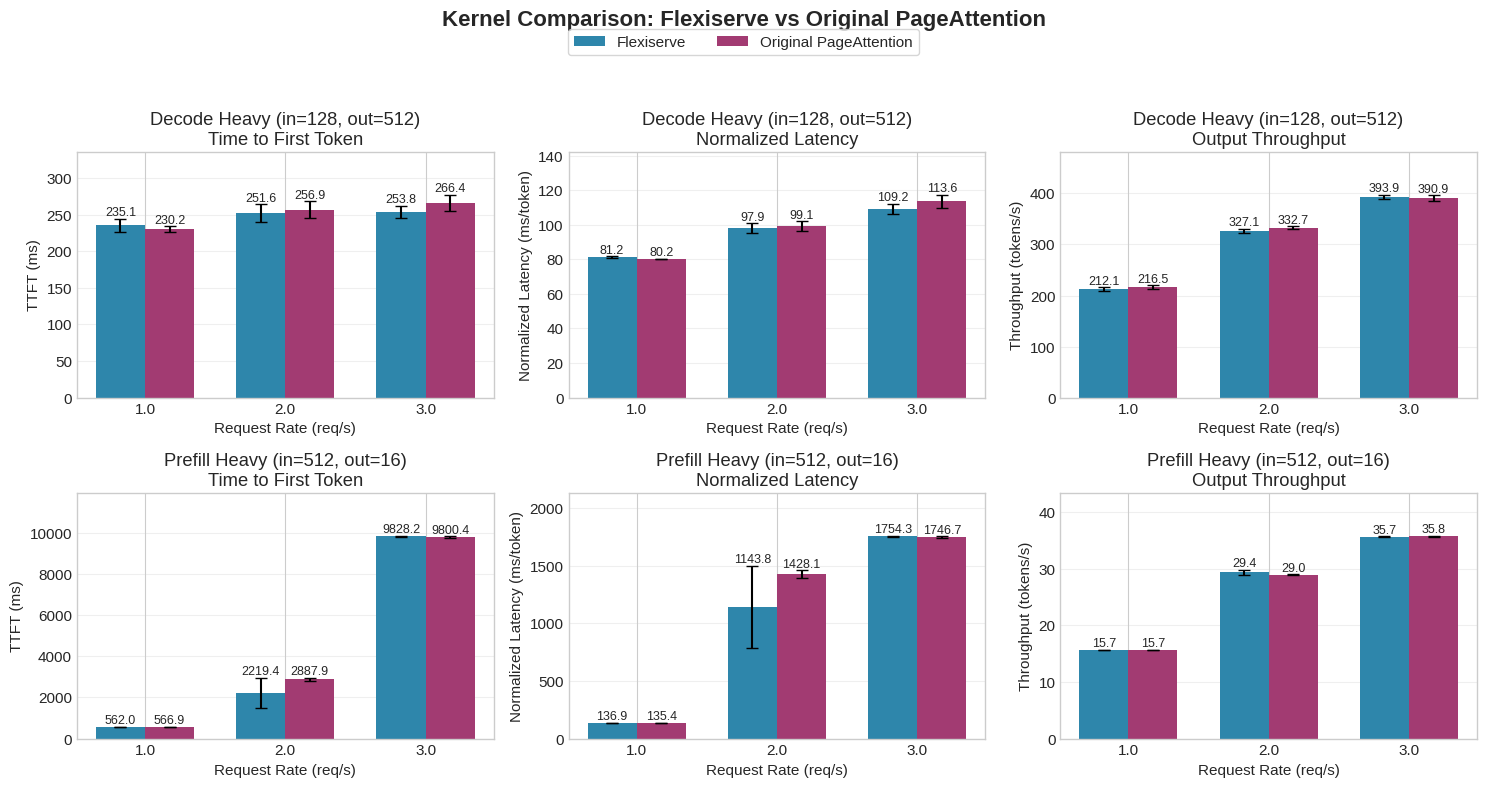

In [7]:
# 使用柱状图比较两个kernel，两种workload放在一起，显示标准差误差线
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Kernel Comparison: Flexiserve vs Original PageAttention', fontsize=16, fontweight='bold')

bar_width = 0.35
colors = {'direct': '#2E86AB', 'flash': '#A23B72'}
legend_labels = ['Flexiserve', 'Original PageAttention']

def add_value_labels(ax, bars, values, yerrs, fontsize=9):
    """在误差线上方添加数值标签"""
    for bar, val, yerr in zip(bars, values, yerrs):
        ax.annotate(f'{val:.1f}', 
                   xy=(bar.get_x() + bar.get_width()/2, bar.get_height() + yerr),
                   ha='center', va='bottom', fontsize=fontsize)

# ========== Row 1: Decode Heavy ==========
df_work = df_decode
workload_name = "Decode Heavy (in=128, out=512)"
df_direct = df_work[df_work['kernel'] == 'direct'].sort_values('rr')
df_flash = df_work[df_work['kernel'] == 'flash'].sort_values('rr')

rr_values = df_direct['rr'].values
x = np.arange(len(rr_values))

# TTFT with error bars
ax = axes[0, 0]
bars1 = ax.bar(x - bar_width/2, df_direct['ttft_ms'].values, bar_width, label=legend_labels[0], color=colors['direct'],
       yerr=df_direct['ttft_std'].values, capsize=4, error_kw={'linewidth': 1.5})
bars2 = ax.bar(x + bar_width/2, df_flash['ttft_ms'].values, bar_width, label=legend_labels[1], color=colors['flash'],
       yerr=df_flash['ttft_std'].values, capsize=4, error_kw={'linewidth': 1.5})
global_legend_handles = [bars1[0], bars2[0]]
add_value_labels(ax, bars1, df_direct['ttft_ms'].values, df_direct['ttft_std'].values)
add_value_labels(ax, bars2, df_flash['ttft_ms'].values, df_flash['ttft_std'].values)
ax.set_xlabel('Request Rate (req/s)')
ax.set_ylabel('TTFT (ms)')
ax.set_title(f'{workload_name}\nTime to First Token')
ax.set_xticks(x)
ax.set_xticklabels(rr_values)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

# Normalized Latency with error bars
ax = axes[0, 1]
bars1 = ax.bar(x - bar_width/2, df_direct['normalized_latency_ms'].values, bar_width, label=legend_labels[0], color=colors['direct'],
       yerr=df_direct['normalized_latency_std'].values, capsize=4, error_kw={'linewidth': 1.5})
bars2 = ax.bar(x + bar_width/2, df_flash['normalized_latency_ms'].values, bar_width, label=legend_labels[1], color=colors['flash'],
       yerr=df_flash['normalized_latency_std'].values, capsize=4, error_kw={'linewidth': 1.5})
add_value_labels(ax, bars1, df_direct['normalized_latency_ms'].values, df_direct['normalized_latency_std'].values)
add_value_labels(ax, bars2, df_flash['normalized_latency_ms'].values, df_flash['normalized_latency_std'].values)
ax.set_xlabel('Request Rate (req/s)')
ax.set_ylabel('Normalized Latency (ms/token)')
ax.set_title(f'{workload_name}\nNormalized Latency')
ax.set_xticks(x)
ax.set_xticklabels(rr_values)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

# Throughput with error bars
ax = axes[0, 2]
bars1 = ax.bar(x - bar_width/2, df_direct['throughput'].values, bar_width, label=legend_labels[0], color=colors['direct'],
       yerr=df_direct['throughput_std'].values, capsize=4, error_kw={'linewidth': 1.5})
bars2 = ax.bar(x + bar_width/2, df_flash['throughput'].values, bar_width, label=legend_labels[1], color=colors['flash'],
       yerr=df_flash['throughput_std'].values, capsize=4, error_kw={'linewidth': 1.5})
add_value_labels(ax, bars1, df_direct['throughput'].values, df_direct['throughput_std'].values)
add_value_labels(ax, bars2, df_flash['throughput'].values, df_flash['throughput_std'].values)
ax.set_xlabel('Request Rate (req/s)')
ax.set_ylabel('Throughput (tokens/s)')
ax.set_title(f'{workload_name}\nOutput Throughput')
ax.set_xticks(x)
ax.set_xticklabels(rr_values)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

# ========== Row 2: Prefill Heavy ==========
df_work = df_prefill
workload_name = "Prefill Heavy (in=512, out=16)"
df_direct = df_work[df_work['kernel'] == 'direct'].sort_values('rr')
df_flash = df_work[df_work['kernel'] == 'flash'].sort_values('rr')

rr_values = df_direct['rr'].values
x = np.arange(len(rr_values))

# TTFT with error bars
ax = axes[1, 0]
bars1 = ax.bar(x - bar_width/2, df_direct['ttft_ms'].values, bar_width, label=legend_labels[0], color=colors['direct'],
       yerr=df_direct['ttft_std'].values, capsize=4, error_kw={'linewidth': 1.5})
bars2 = ax.bar(x + bar_width/2, df_flash['ttft_ms'].values, bar_width, label=legend_labels[1], color=colors['flash'],
       yerr=df_flash['ttft_std'].values, capsize=4, error_kw={'linewidth': 1.5})
add_value_labels(ax, bars1, df_direct['ttft_ms'].values, df_direct['ttft_std'].values)
add_value_labels(ax, bars2, df_flash['ttft_ms'].values, df_flash['ttft_std'].values)
ax.set_xlabel('Request Rate (req/s)')
ax.set_ylabel('TTFT (ms)')
ax.set_title(f'{workload_name}\nTime to First Token')
ax.set_xticks(x)
ax.set_xticklabels(rr_values)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

# Normalized Latency with error bars
ax = axes[1, 1]
bars1 = ax.bar(x - bar_width/2, df_direct['normalized_latency_ms'].values, bar_width, label=legend_labels[0], color=colors['direct'],
       yerr=df_direct['normalized_latency_std'].values, capsize=4, error_kw={'linewidth': 1.5})
bars2 = ax.bar(x + bar_width/2, df_flash['normalized_latency_ms'].values, bar_width, label=legend_labels[1], color=colors['flash'],
       yerr=df_flash['normalized_latency_std'].values, capsize=4, error_kw={'linewidth': 1.5})
add_value_labels(ax, bars1, df_direct['normalized_latency_ms'].values, df_direct['normalized_latency_std'].values)
add_value_labels(ax, bars2, df_flash['normalized_latency_ms'].values, df_flash['normalized_latency_std'].values)
ax.set_xlabel('Request Rate (req/s)')
ax.set_ylabel('Normalized Latency (ms/token)')
ax.set_title(f'{workload_name}\nNormalized Latency')
ax.set_xticks(x)
ax.set_xticklabels(rr_values)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

# Throughput with error bars
ax = axes[1, 2]
bars1 = ax.bar(x - bar_width/2, df_direct['throughput'].values, bar_width, label=legend_labels[0], color=colors['direct'],
       yerr=df_direct['throughput_std'].values, capsize=4, error_kw={'linewidth': 1.5})
bars2 = ax.bar(x + bar_width/2, df_flash['throughput'].values, bar_width, label=legend_labels[1], color=colors['flash'],
       yerr=df_flash['throughput_std'].values, capsize=4, error_kw={'linewidth': 1.5})
add_value_labels(ax, bars1, df_direct['throughput'].values, df_direct['throughput_std'].values)
add_value_labels(ax, bars2, df_flash['throughput'].values, df_flash['throughput_std'].values)
ax.set_xlabel('Request Rate (req/s)')
ax.set_ylabel('Throughput (tokens/s)')
ax.set_title(f'{workload_name}\nOutput Throughput')
ax.set_xticks(x)
ax.set_xticklabels(rr_values)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

fig.legend(global_legend_handles, legend_labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 0.965), frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig('/home/bxb1/vllm_workbench/vllm/SOSP-Paper-Xu-Bai-/Figures/eval-kernel-cmp.pdf', format='pdf', bbox_inches='tight')
plt.show()